# **AI Agent 기초**

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더 `ai_agent`를 생성(이미 만들었다면 skip)
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### (2) 라이브러리

* 필요한 라이브러리 설치

In [ ]:
!pip install langchain-openai langchain_community -q

* 라이브러리 로딩

In [ ]:
import pandas as pd
import numpy as np
import os
import openai

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage
from langgraph.graph import StateGraph, START, END

### (3) API Key 설정

In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/ai_agent/'

# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

* ⚠️ api_key가 잘 등록되었는지 확인

In [ ]:
print(os.environ['OPENAI_API_KEY'][:40])

## **2. 단순 Agent 만들기**

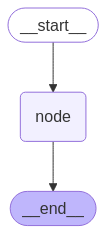

### **(1) State 정의 및 llm 준비**
- 그래프의 노드의 입력과 출력 관리하는 딕셔너리 형태의 자료형
- 그래프를 통과하며, 컨텍스트를 유지


In [ ]:
from langgraph.graph import MessagesState

class SimpleState(MessagesState):
    response: str

In [ ]:
llm = ChatOpenAI(model = "gpt-4.1-mini")

### **(2) 노드 준비**

In [ ]:
def chatbot(state: SimpleState):
    # 1. State에서 필요한 정보 저장
    prompt = state["messages"]

    # 2. prompt 구성

    # 3. llm 호출
    result = llm.invoke(prompt)

    # 4. state 업데이트
    return {"messages": result, "response": result.content}

### **(3) 그래프 구성**

In [ ]:
# 그래프 초기화
builder = StateGraph(SimpleState)

# 노드 추가
builder.add_node("chatbot", chatbot)

# 엣지 추가
builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

# 컴파일
graph = builder.compile()

In [ ]:
graph

### **(4) Graph 실행**
- 입력 : State 딕셔너리 형식. 특정 키만 입력 가능
- 출력 : State 딕셔너리 형식.


In [ ]:
# 초기 state 준비
initial_state = {"messages": "오늘 서울 기온은?"}

# 그래프 실행
result = graph.invoke(initial_state)

* 결과 열어보기

In [ ]:
# 전체 결과
result

In [ ]:
# messages
result['messages']

In [ ]:
# response
result['response']

In [ ]:
# messages에 쌓인 내용을 순차적으로 출력하기
for m in result["messages"]:
    m.pretty_print()

### **(5) 실습🔥**

* 위 단순 Agent 구조를 참고하여, **시스템 메시지로 역할을 지정한** AI Agent를 만들어봅시다.
* 국내 여행지를 추천해주는 **여행지 추천 에이전트**
    * 사용자의 요청(계절, 취향, 동행자 등)을 참고해서 어울리는 국내 여행지를 추천
    * 시스템 메시지로 역할, 답변 지침, 말투 등을 지정

#### **1) State 정의 및 llm 준비**

In [ ]:
class TravelState(MessagesState):
    response: str

In [ ]:
llm = ChatOpenAI(model = "gpt-4.1-mini")

#### **2) 노드 준비**

In [ ]:
def travel_agent(state: TravelState):
    # 1. State에서 필요한 정보 저장
    user_input = state["messages"][-1].content

    # 2. prompt 구성
    # SystemMessage에 "여행지 추천 에이전트" 역할과 답변 지침, 말투를 지정하세요.
    # HumanMessage에는 user_input을 담으세요.


    # 3. llm 호출
    # llm.invoke([system, human]) 형태로 호출하고 결과를 변수에 저장하세요.


    # 4. state 업데이트
    # {"messages": 호출 결과, "response": 호출 결과.content} 형태로 반환하세요.


#### **3) 그래프 구성**

In [ ]:
# 그래프 생성


# 노드 등록


# 연결


# 컴파일


In [ ]:
graph

#### **4) Graph 실행**

In [ ]:
initial_state = {"messages": "여름에 시원하게 놀 수 있는 국내 여행지 추천해줘"}

result = graph.invoke(initial_state)

for m in result["messages"]:
    m.pretty_print()

## **3. State 이해**

In [ ]:
# 딕셔너리/json 형식을 보기 좋게 출력하는 함수
from pprint import pprint
import ast

### (1) 그래프 생성
* State 준비

In [ ]:
class AgentState(MessagesState):
    user_input: str
    key_point: str
    action_item: list

* 노드 준비

In [ ]:
llm = ChatOpenAI(model = "gpt-4.1-mini")

In [ ]:
def keypoint_agent(state: AgentState):
    # 입력 State 출력
    print('입력값(초기값)')
    pprint(state, width=100, sort_dicts=False)
    print('='*200)

    # 1. State로 부터 필요한 정보 가져오기
    user_input = state['messages'][-1].content

    # 2. 프롬프트 구성
    system = SystemMessage(
        content= '''
        # 역할 : 사용자 입력에서 핵심 문제점 2개를 도출하는 에이전트.
        # 출력 : 블릿포인트 형식.\n'''
    )
    human = HumanMessage(content=user_input)

    # 3. llm 호출
    result = llm.invoke([system, human])

    # 4. State 업데이트
    return {"messages": result,
            "user_input": user_input,
            "key_point": result.content}

In [ ]:
def solution_agent(state: AgentState):
    # 입력 State 출력
    print('Agent1 실행 결과')
    pprint(state, width=100, sort_dicts=False)

    # 1. State로 부터 필요한 정보 가져오기
    user_input = state.get("user_input")
    key_point = state.get("key_point")

    # 2. 프롬프트 구성
    system = SystemMessage('''
        # 역할 : 핵심 문제점에 대한 후속 조치를 2개를 도출하는 에이전트.
        # 출력형식
        - 리스트 형식.
        - 답변에 후속조치를 담는 리스트(list) 외에 어떠한 답변도 달지마.
        - 예 : ['후속조치1','후속조치2']''')

    human = HumanMessage(f'''
        # 사용자 입력:
        {user_input}

        # 핵심 문제점:
        {key_point}''')

    # 3. llm 호출
    result = llm.invoke([system, human])
    action = ast.literal_eval(result.content)

    # 4. State 업데이트
    return {"messages": result, "action_item": action}

* 그래프 생성

In [ ]:
workflow = StateGraph(AgentState)

workflow.add_node("Agent1", keypoint_agent)
workflow.add_node("Agent2", solution_agent)

workflow.add_edge(START, "Agent1")
workflow.add_edge("Agent1", "Agent2")
workflow.add_edge("Agent2", END)

graph = workflow.compile()

In [ ]:
graph

### (2) 그래프 실행
* 중간 단계 State 보기
    * 초기값(입력값)
    * Agent1 실행결과

In [ ]:
text = '''이번 달 말에 대대적으로 출시하기로 한 신규 모바일 앱 프로젝트가 정말 큰 위기에 봉착했습니다.
어제 밤사이 메인 개발 서버가 갑자기 최신형 랜섬웨어 공격을 받아서 모든 소스 코드와 DB가 암호화되어 버렸습니다.
보안 팀에서 급하게 복구를 시도해봤지만, 해커가 요구하는 암호화 해제 비용이 예산을 초과하여 사실상 기술적 복구가 불가능하다는 결론을 내렸습니다.
'''

# 초기 State 설정 및 실행
initial_state = {"messages": [HumanMessage(text)]}
result = graph.invoke(initial_state)

### (3) 최종 State 보기

In [ ]:
pprint(result, width=100, sort_dicts=False)

### **(4) 실습🔥**

* 위 2단계 파이프라인(node1 → node2)에 이어, 핵심 문제점과 후속조치를 종합해서 최종 보고서를 작성하는 node3(report_agent)를 추가해봅시다.
* `AgentState`에 `final_report` 필드를 추가하고, 그래프를 `node1 → node2 → node3` 순서로 재구성하세요.

#### **1) State 정의 및 Node 준비**

In [ ]:
class AgentState(MessagesState):
    user_input: str
    key_point: str
    action_item: list
    final_report: str  # <--추가

In [ ]:
def report_agent(state: AgentState):
    # 입력 State 출력
    print('Agent2 실행 결과')
    pprint(state, width=100, sort_dicts=False)
    print('='*200)

    # 1. State로 부터 필요한 정보 가져오기
    # user_input, key_point, action_item 세 가지를 state에서 꺼내오세요.


    # 2. 프롬프트 구성
    # SystemMessage: "핵심 문제점과 후속조치를 종합해서 최종 보고서를 작성하는 에이전트" 역할 지정
    # HumanMessage: user_input, key_point, action_item을 모두 포함해서 전달
    sys_msg = SystemMessage(    )
    hu_msg = HumanMessage(   )

    # 3. llm 호출
    # llm.invoke([sys_msg, hu_msg])로 호출하고 결과를 저장하세요.


    # 4. State 업데이트
    # {"messages": 결과, "final_report": 결과.content} 형태로 반환하세요.


#### **2) 그래프 구성**

In [ ]:
graph

#### **3) 그래프 실행 및 결과 확인**

In [ ]:
text = '''이번 달 말에 대대적으로 출시하기로 한 신규 모바일 앱 프로젝트가 정말 큰 위기에 봉착했습니다.
어제 밤사이 메인 개발 서버가 갑자기 최신형 랜섬웨어 공격을 받아서 모든 소스 코드와 DB가 암호화되어 버렸습니다.
보안 팀에서 급하게 복구를 시도해봤지만, 해커가 요구하는 암호화 해제 비용이 예산을 초과하여 사실상 기술적 복구가 불가능하다는 결론을 내렸습니다.
'''

# 초기 State 설정 및 실행
initial_state = {"messages": [HumanMessage(text)]}
result = graph.invoke(initial_state)

In [ ]:
pprint(result, width=100, sort_dicts=False)

### [참조] 딕셔너리로 부터 값 불러오기
* 딕셔너리['키']
* 딕셔너리.get('키')
* 딕셔너리.get('키', 키가 없을 때 대체할 값)

In [ ]:
text = '이번 달 말에 대대적으로 출시하기로 한 신규 모바일 앱 프로젝트가 정말 큰 위기에 봉착했습니다.'

# 초기 State 설정 및 실행
initial_state = {"messages": [HumanMessage(text)], "action_item":['aaa']}

In [ ]:
print(initial_state['action_item'])
print(initial_state.get('action_item'))
print(initial_state.get('action_item', ''))

In [ ]:
print(initial_state['key_point'])         # 키가 없으면 오류
print(initial_state.get('key_point'))       # 키가 없으면 None 출력
print(initial_state.get('key_point', 'n'))  # 키가 없으면 'n' 출력